# Artificial Intelligence Technology and Application

## AI Final Exam Lab - Student Version

Independent implementation prepared by **Sundetkhan Bekzat**.


# 1 Handwritten Digit Recognition Final Lab

This notebook keeps the lab objective but uses compact local examples so it can run without external datasets.


## 1.1 Dataset Acquisition
The final lab uses the built-in handwritten digits dataset so the notebook remains local and repeatable.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

digits_bundle = load_digits()
digit_images = digits_bundle.images.astype("float32")
digit_labels = digits_bundle.target
flat_pixels = digit_images.reshape(len(digit_images), -1)
train_pixels, test_pixels, train_digits, test_digits = train_test_split(
    flat_pixels, digit_labels, test_size=0.25, stratify=digit_labels, random_state=120
)
pixel_scaler = StandardScaler().fit(train_pixels)
train_scaled = pixel_scaler.transform(train_pixels)
test_scaled = pixel_scaler.transform(test_pixels)
print("digit image tensor:", digit_images.shape)
print("train/test rows:", train_scaled.shape, test_scaled.shape)


digit image tensor: (1797, 8, 8)
train/test rows: (1347, 64) (450, 64)


## 1.2 Image Grid
A sample grid confirms how each handwritten digit is encoded as an 8x8 numeric image.


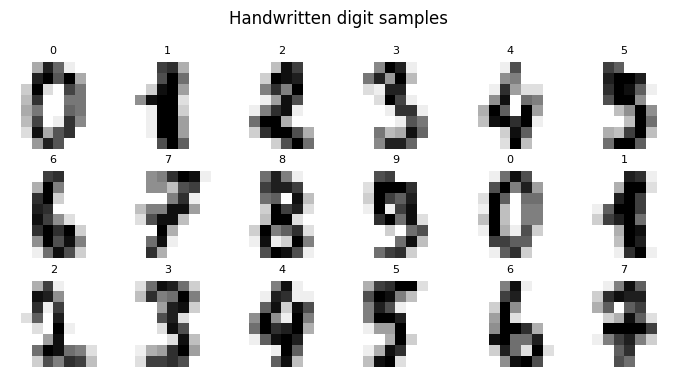

In [2]:
fig, axes = plt.subplots(3, 6, figsize=(7, 3.8))
for ax, image, label in zip(axes.ravel(), digit_images[:18], digit_labels[:18]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(str(label), fontsize=8)
    ax.axis("off")
fig.suptitle("Handwritten digit samples")
plt.tight_layout()
plt.show()


## 1.3 Dense Neural Network
The dense model flattens the image and learns class boundaries with hidden layers.


In [3]:
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

dense_digit_net = MLPClassifier(
    hidden_layer_sizes=(96, 48), activation="relu", max_iter=140, early_stopping=True, random_state=120
)
dense_digit_net.fit(train_scaled, train_digits)
dense_predictions = dense_digit_net.predict(test_scaled)
dense_accuracy = accuracy_score(test_digits, dense_predictions)
print("DNN-style accuracy:", round(dense_accuracy, 3))
print("training iterations:", dense_digit_net.n_iter_)


DNN-style accuracy: 0.942
training iterations: 25


## 1.4 CNN-Style Spatial Feature Model
Instead of copying the TensorFlow CNN, this version extracts local patch and edge features before classification.


In [4]:
from sklearn.linear_model import LogisticRegression

def spatial_digit_descriptor(flat_batch):
    image_batch = flat_batch.reshape(-1, 8, 8)
    row_edges = np.abs(np.diff(image_batch, axis=1)).mean(axis=2)
    col_edges = np.abs(np.diff(image_batch, axis=2)).mean(axis=1)
    quadrants = np.stack([
        image_batch[:, :4, :4].mean(axis=(1, 2)),
        image_batch[:, :4, 4:].mean(axis=(1, 2)),
        image_batch[:, 4:, :4].mean(axis=(1, 2)),
        image_batch[:, 4:, 4:].mean(axis=(1, 2)),
    ], axis=1)
    center_mass = image_batch[:, 2:6, 2:6].mean(axis=(1, 2), keepdims=False).reshape(-1, 1)
    return np.concatenate([flat_batch, row_edges, col_edges, quadrants, center_mass], axis=1)

train_spatial = spatial_digit_descriptor(train_pixels / 16.0)
test_spatial = spatial_digit_descriptor(test_pixels / 16.0)
spatial_digit_net = LogisticRegression(max_iter=700, solver="lbfgs")
spatial_digit_net.fit(train_spatial, train_digits)
spatial_predictions = spatial_digit_net.predict(test_spatial)
spatial_accuracy = accuracy_score(test_digits, spatial_predictions)
print("CNN-style spatial accuracy:", round(spatial_accuracy, 3))


CNN-style spatial accuracy: 0.978


## 1.5 Model Comparison
Both approaches are compared with the same test split.


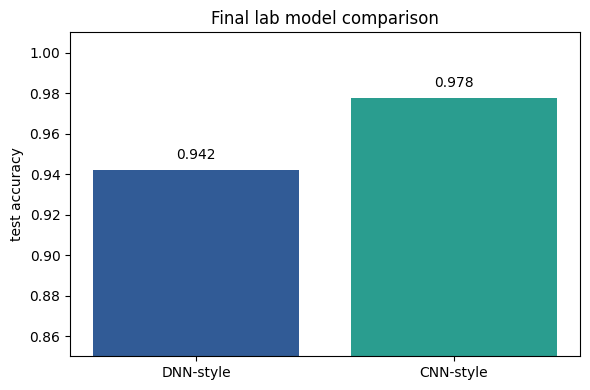

In [5]:
comparison_names = ["DNN-style", "CNN-style"]
comparison_scores = [dense_accuracy, spatial_accuracy]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(comparison_names, comparison_scores, color=["#315b96", "#2a9d8f"])
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("test accuracy")
ax.set_title("Final lab model comparison")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{bar.get_height():.3f}", ha="center")
plt.tight_layout()
plt.show()


## 1.6 Confusion Matrix and Deployment Check
The better model is inspected through a confusion matrix and a small prediction grid.


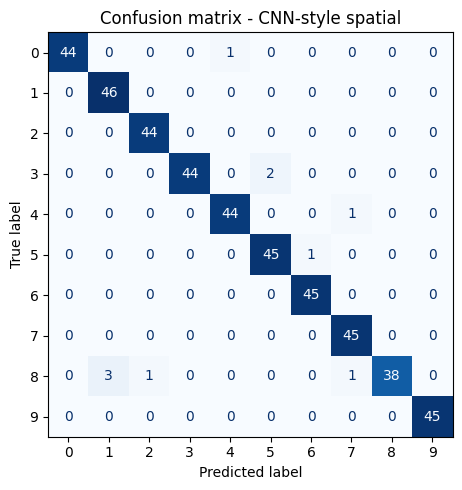

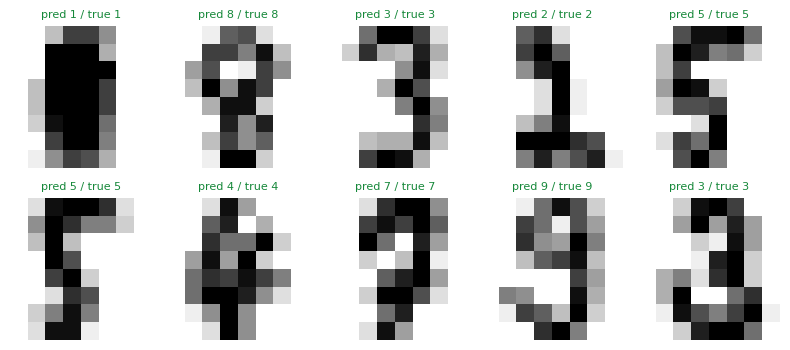

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

final_predictions = spatial_predictions if spatial_accuracy >= dense_accuracy else dense_predictions
final_title = "CNN-style spatial" if spatial_accuracy >= dense_accuracy else "DNN-style dense"
matrix = confusion_matrix(test_digits, final_predictions, labels=np.arange(10))
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matrix, display_labels=np.arange(10)).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix - {final_title}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(8, 3.7))
test_images = test_pixels.reshape(-1, 8, 8)
for ax, image, truth, pred in zip(axes.ravel(), test_images[:10], test_digits[:10], final_predictions[:10]):
    ax.imshow(image, cmap="gray_r")
    ax.set_title(f"pred {pred} / true {truth}", fontsize=8, color="#16883a" if pred == truth else "#b22222")
    ax.axis("off")
plt.tight_layout()
plt.show()
